# Imbalance Direction

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('../data_samples/energinet_imbalance_prices_2024-2026.csv')

df = df[['TimeUTC','DominatingDirection']]

In [7]:
from src.scenarios.imbalance_direction.markov_chain import MarkovChainModel

model = MarkovChainModel()
model.fit(df)  # df with "TimeUTC" and "DominatingDirection"

scenarios = model.generate(
    n_scenarios=200,
    seed=42,
    initial_state=-1,   # last observed direction
    start_hour=0,        # hour of day for first step
)

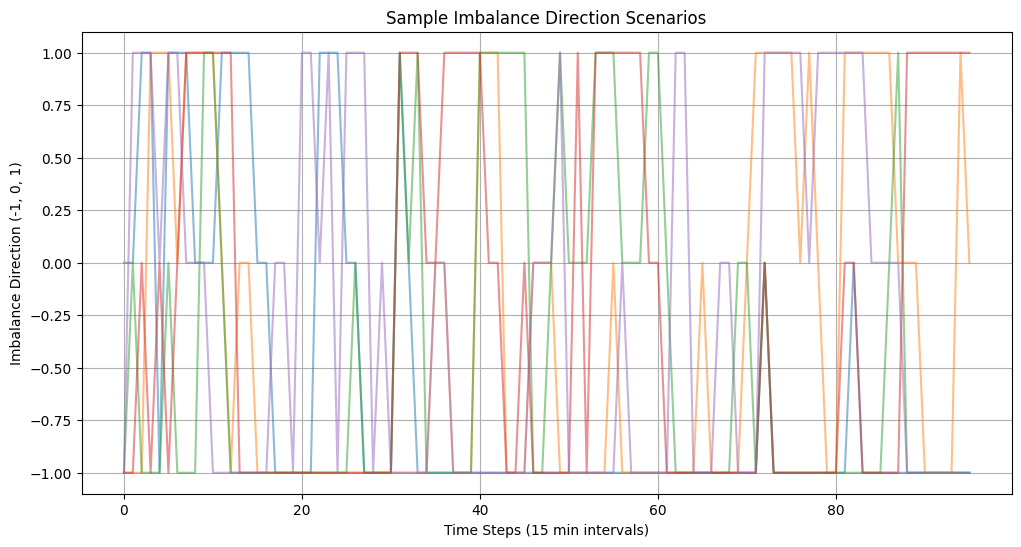

In [15]:
#plot scenarios
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(5):  # plot first 20 scenarios
    plt.plot(scenarios[i], alpha=0.5)
plt.title("Sample Imbalance Direction Scenarios")
plt.xlabel("Time Steps (15 min intervals)")
plt.ylabel("Imbalance Direction (-1, 0, 1)")
plt.grid()
plt.show()

In [16]:
# value counts

import numpy as np
scenarios_flat = scenarios.flatten()
unique, counts = np.unique(scenarios_flat, return_counts=True)
print("Value counts in generated scenarios:")
for val, count in zip(unique, counts):
    print(f"Value {val}: {count} occurrences ({count / len(scenarios_flat) * 100:.2f}%)")

Value counts in generated scenarios:
Value -1: 11464 occurrences (59.71%)
Value 0: 3213 occurrences (16.73%)
Value 1: 4523 occurrences (23.56%)


In [17]:
# save 
model.save("../trained_models/imbalance_direction/markov_chain.npy")